In [7]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
# Load Dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Use a subset of training data for faster training
subset_size = 20000
train_images = train_images[:subset_size]
train_labels = train_labels[:subset_size]

In [9]:
# Preprocess Data
train_images = train_images.reshape((subset_size, 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [11]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)


In [12]:
# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
# Train Model
batch_size = 64
epochs = 15

history = model.fit(datagen.flow(train_images, train_labels, batch_size=batch_size),
                    validation_data=(test_images, test_labels),
                    epochs=epochs)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 242ms/step - accuracy: 0.5930 - loss: 1.1888 - val_accuracy: 0.9761 - val_loss: 0.0732
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 247ms/step - accuracy: 0.9013 - loss: 0.3115 - val_accuracy: 0.9851 - val_loss: 0.0482
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.9278 - loss: 0.2329 - val_accuracy: 0.9870 - val_loss: 0.0370
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.9467 - loss: 0.1751 - val_accuracy: 0.9853 - val_loss: 0.0436
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 244ms/step - accuracy: 0.9546 - loss: 0.1497 - val_accuracy: 0.9898 - val_loss: 0.0293
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.9587 - loss: 0.1348 - val_accuracy: 0.9902 - val_loss: 0.0272
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step - accuracy: 0.9646 - loss: 0.1201 - val_accuracy: 0.9910 - val_loss: 0.0266
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step - accuracy: 0.9652 - loss: 0.1143 - val

In [15]:
# Evaluate Model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9912 - loss: 0.0227
Test Accuracy: 0.9929999709129333


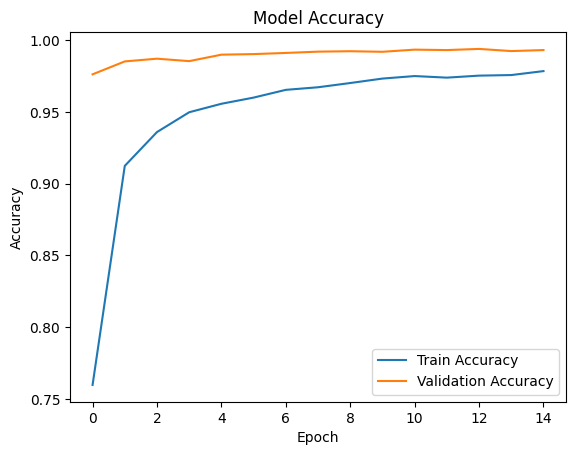

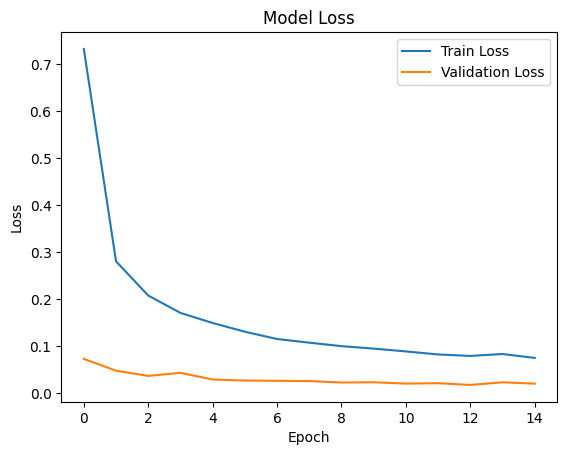

In [16]:
# Visualize Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


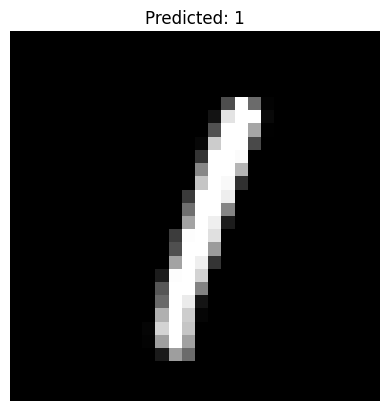

In [17]:
# Class names
class_names = [str(i) for i in range(10)]

# Predict a single test image
idx = 5  # change index to test different images
img = test_images[idx].reshape(1, 28, 28, 1)
pred = model.predict(img)
pred_label = class_names[np.argmax(pred)]

plt.imshow(test_images[idx].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {pred_label}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


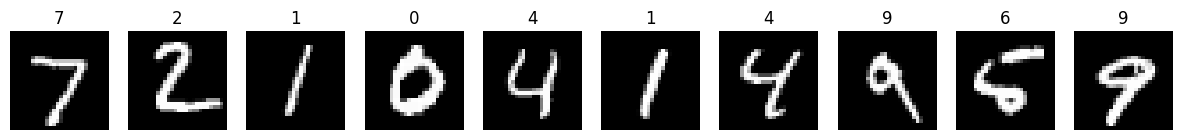

In [18]:
# Predict multiple test images
num_test = 10
plt.figure(figsize=(15,4))
for i in range(num_test):
    img = test_images[i].reshape(1,28,28,1)
    pred = model.predict(img)
    pred_label = class_names[np.argmax(pred)]

    plt.subplot(1,num_test,i+1)
    plt.imshow(test_images[i].reshape(28,28), cmap='gray')
    plt.title(pred_label)
    plt.axis('off')
plt.show()